In [1]:
!pip install -q transformers accelerate scikit-learn safetensors

In [2]:
# ============================================================
# ICORE GENERALIZABILITY NOTEBOOK
# Loads saved models + runs iCORE predictions
# No training — inference only
# ============================================================

# ============================================================
# BLOCK 1 — IMPORTS
# ============================================================
import os
import gc
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from collections import OrderedDict
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
from torch.utils.data import Dataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ Imports done")

✅ Imports done


In [3]:
# ============================================================
# BLOCK 2 — EXTRACT AND LOAD mBERT MODELS
# ============================================================
import os
import subprocess

# Extract zips
for f in ["thesis_mbert_binary_model.zip", "thesis_mbert_dist_model.zip"]:
    fpath = f"/content/{f}"
    if os.path.exists(fpath):
        print(f"Extracting {f}...")
        subprocess.run(["unzip", "-o", fpath, "-d", "/content"])
        print(f"✅ Extracted {f}")
    else:
        print(f"❌ Not found: {f} — upload it first")

MODEL_CHOICE = "mbert"

# Verify
print(f"\n✅ mBERT models ready")
print(f"  best_binary_model     : {os.path.exists('./best_binary_model')}")
print(f"  best_distortion_model : {os.path.exists('./best_distortion_model')}")

print("\nBinary model files:")
for f in sorted(os.listdir("./best_binary_model")):
    print(" ", f)
print("\nDistortion model files:")
for f in sorted(os.listdir("./best_distortion_model")):
    print(" ", f)

Extracting thesis_mbert_binary_model.zip...
✅ Extracted thesis_mbert_binary_model.zip
Extracting thesis_mbert_dist_model.zip...
✅ Extracted thesis_mbert_dist_model.zip

✅ mBERT models ready
  best_binary_model     : True
  best_distortion_model : True

Binary model files:
  config.json
  model.safetensors
  threshold.json
  tokenizer.json
  tokenizer_config.json
  training_args.bin

Distortion model files:
  config.json
  label_map.json
  model.safetensors
  tokenizer.json
  tokenizer_config.json
  training_args.bin


In [4]:
# ============================================================
# BLOCK 3 — TOKENIZER + DATASET CLASS
# Loads tokenizer from saved binary model
# ============================================================
tokenizer     = AutoTokenizer.from_pretrained("./best_binary_model")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

class TextDataset(Dataset):
    def __init__(self, dataframe, tokenizer, text_col, label_col, max_len=128):
        self.texts     = dataframe[text_col].tolist()
        self.labels    = dataframe[label_col].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
        )
        enc["labels"] = int(self.labels[idx])
        return enc

print(f"✅ Tokenizer loaded from ./best_binary_model")
print(f"✅ TextDataset defined")

✅ Tokenizer loaded from ./best_binary_model
✅ TextDataset defined


In [5]:
# ============================================================
# BLOCK 4 — LOAD MODEL METADATA
# Reads threshold + label map from saved models
# ============================================================

# Binary threshold
with open("./best_binary_model/threshold.json") as f:
    best_threshold = json.load(f)["threshold"]
print(f"[ICORE] Binary threshold : {best_threshold}")

# Distortion label map
with open("./best_distortion_model/label_map.json") as f:
    label_map  = json.load(f)
    id2dist_ic = {int(k): v for k, v in label_map["id2dist"].items()}
    dist2id_ic = {v: int(k) for k, v in label_map["id2dist"].items()}

target_names_ic = [id2dist_ic[i] for i in range(len(id2dist_ic))]
print(f"[ICORE] Distortion classes : {target_names_ic}")
print("✅ Metadata loaded")

[ICORE] Binary threshold : 0.45
[ICORE] Distortion classes : ['Catastrophizing', 'Comparing', 'Dichotomous Thinking', 'Emotional Reasoning', 'Filtering', 'Labelling', 'Regret Orientation', 'Should Statement']
✅ Metadata loaded


In [6]:
# ============================================================
# BLOCK 5 — LOAD ICORE DATASET
# Upload icore_cleaned.csv to Colab first
# ============================================================
ICORE_PATH = "icore_cleaned.csv"
for candidate in [ICORE_PATH, "/content/icore_cleaned.csv"]:
    if os.path.exists(candidate):
        ICORE_PATH = candidate
        break

icore_df = None
for encoding in ["utf-8", "latin-1", "cp1252", "utf-8-sig"]:
    try:
        icore_df = pd.read_csv(ICORE_PATH, encoding=encoding)
        print(f"✅ iCORE loaded with encoding: {encoding}")
        break
    except UnicodeDecodeError:
        print(f"❌ Failed: {encoding}")

if icore_df is None:
    raise ValueError("Could not load icore_cleaned.csv — upload it first")

icore_df = icore_df.dropna(subset=["sentence", "label"]).copy()
icore_df["sentence"] = icore_df["sentence"].astype(str).str.strip()
icore_df["label"]    = icore_df["label"].astype(int)
icore_df["language"] = icore_df["language"].astype(str).str.strip()
icore_df = icore_df[icore_df["sentence"].str.len() > 0].reset_index(drop=True)

print("\n" + "="*55)
print("iCORE DATASET")
print("="*55)
print(f"Total samples  : {len(icore_df)}")
print(f"Label dist     :\n{icore_df['label'].value_counts()}")
print(f"Language dist  :\n{icore_df['language'].value_counts()}")

icore_df["length"] = icore_df["sentence"].str.split().str.len()
print(f"\nLength stats by label:")
print(icore_df.groupby("label")["length"].describe()[["mean","50%","min","max"]])
icore_df = icore_df.drop(columns=["length"])
print("✅ iCORE dataset loaded")

✅ iCORE loaded with encoding: utf-8

iCORE DATASET
Total samples  : 1172
Label dist     :
label
0    586
1    586
Name: count, dtype: int64
Language dist  :
language
English     586
Filipino    586
Name: count, dtype: int64

Length stats by label:
            mean   50%  min    max
label                             
0      16.561433  13.5  2.0   80.0
1      22.206485  17.0  2.0  234.0
✅ iCORE dataset loaded


In [7]:
# ============================================================
# BLOCK 6 — CLEAR GPU MEMORY
# Run before loading models to avoid OOM errors
# ============================================================
gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU allocated : {allocated:.2f} GB")
    print(f"GPU free      : {total - allocated:.2f} GB")
    print(f"GPU total     : {total:.2f} GB")

print("✅ GPU memory cleared — ready for inference")

GPU allocated : 0.00 GB
GPU free      : 14.56 GB
GPU total     : 14.56 GB
✅ GPU memory cleared — ready for inference


In [8]:
# ============================================================
# BLOCK 7 — BINARY PREDICTION ON ICORE
# ============================================================
icore_bin_dataset = TextDataset(
    icore_df, tokenizer, "sentence", "label", max_len=128
)
print(f"\n[ICORE] Binary test samples : {len(icore_bin_dataset)}")

bin_model_icore = AutoModelForSequenceClassification.from_pretrained(
    "./best_binary_model"
)
bin_model_icore.eval()

icore_pred = Trainer(
    model=bin_model_icore,
    args=TrainingArguments(
        output_dir="./eval_tmp_icore_bin",
        per_device_eval_batch_size=8,
        report_to="none",
        fp16=False,
    ),
    data_collator=data_collator,
).predict(icore_bin_dataset)

icore_y_true     = icore_pred.label_ids
icore_logits     = icore_pred.predictions
icore_probs      = torch.softmax(
    torch.tensor(icore_logits, dtype=torch.float), dim=-1
).numpy()
icore_class1     = icore_probs[:, 1]
icore_y_pred_thr = (icore_class1 >= best_threshold).astype(int)

# Metrics
fpr_ic, tpr_ic, thr_ic = roc_curve(icore_y_true, icore_class1)
roc_auc_ic = auc(fpr_ic, tpr_ic)

precision_ic, recall_ic, f1_ic, _ = precision_recall_fscore_support(
    icore_y_true, icore_y_pred_thr, average="weighted", zero_division=0
)
acc_ic       = accuracy_score(icore_y_true, icore_y_pred_thr)
report_ic    = classification_report(
    icore_y_true, icore_y_pred_thr, output_dict=True, zero_division=0
)
distorted_f1_ic = report_ic.get("1", {}).get("f1-score", 0.0)

print("\n" + "="*55)
print("BINARY RESULTS — iCORE DATASET")
print("="*55)
print(f"Threshold     : {best_threshold}")
print(f"Accuracy      : {acc_ic:.4f}")
print(f"Weighted F1   : {f1_ic:.4f}")
print(f"Distorted F1  : {distorted_f1_ic:.4f}")
print(f"ROC-AUC       : {roc_auc_ic:.4f}")
print(f"\nPrediction distribution:")
print(dict(zip(*[x.tolist() for x in np.unique(icore_y_pred_thr, return_counts=True)])))
print("\nConfusion matrix:")
print(confusion_matrix(icore_y_true, icore_y_pred_thr))
print(f"\nClassification report (threshold={best_threshold}):")
print(classification_report(
    icore_y_true, icore_y_pred_thr,
    target_names=["No Distortion", "Distorted"],
    digits=4,
))

# Save to icore_df
icore_df["predicted_label"]        = icore_y_pred_thr
icore_df["distortion_probability"] = icore_class1.round(4)
icore_df["predicted_class"]        = icore_df["predicted_label"].map({
    0: "No Distortion", 1: "Distorted"
})
print("✅ Binary prediction done")


[ICORE] Binary test samples : 1172


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BINARY RESULTS — iCORE DATASET
Threshold     : 0.45
Accuracy      : 0.5930
Weighted F1   : 0.5885
Distorted F1  : 0.5453
ROC-AUC       : 0.6547

Prediction distribution:
{0: 709, 1: 463}

Confusion matrix:
[[409 177]
 [300 286]]

Classification report (threshold=0.45):
               precision    recall  f1-score   support

No Distortion     0.5769    0.6980    0.6317       586
    Distorted     0.6177    0.4881    0.5453       586

     accuracy                         0.5930      1172
    macro avg     0.5973    0.5930    0.5885      1172
 weighted avg     0.5973    0.5930    0.5885      1172

✅ Binary prediction done


In [9]:
# ============================================================
# BLOCK 8 — THRESHOLD SWEEP ON ICORE
# ============================================================
print("\n========== THRESHOLD SWEEP ON iCORE ==========")
ic_results = []
for t in np.arange(0.1, 0.9, 0.05):
    preds_t = (icore_class1 >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        icore_y_true, preds_t,
        average=None, zero_division=0, labels=[0, 1]
    )
    ic_results.append({
        "threshold":        round(float(t), 2),
        "class1_precision": round(float(p[1]), 4),
        "class1_recall":    round(float(r[1]), 4),
        "class1_f1":        round(float(f[1]), 4),
        "class0_recall":    round(float(r[0]), 4),
    })

ic_df    = pd.DataFrame(ic_results)
best_row = ic_df.loc[ic_df["class1_f1"].idxmax()]
print(ic_df.to_string(index=False))
print(f"\n✅ Best threshold on iCORE : {best_row['threshold']}")
print(f"   Class 1 precision       : {best_row['class1_precision']}")
print(f"   Class 1 recall          : {best_row['class1_recall']}")
print(f"   Class 1 F1              : {best_row['class1_f1']}")
print(f"   Class 0 recall          : {best_row['class0_recall']}")
print("✅ Threshold sweep done")


========== THRESHOLD SWEEP ON iCORE ==========
 threshold  class1_precision  class1_recall  class1_f1  class0_recall
      0.10            0.5667         0.8481     0.6794         0.3515
      0.15            0.5749         0.7594     0.6544         0.4386
      0.20            0.5872         0.7065     0.6414         0.5034
      0.25            0.5969         0.6570     0.6255         0.5563
      0.30            0.6068         0.6058     0.6063         0.6075
      0.35            0.6089         0.5631     0.5851         0.6382
      0.40            0.6061         0.5119     0.5550         0.6672
      0.45            0.6177         0.4881     0.5453         0.6980
      0.50            0.6337         0.4488     0.5255         0.7406
      0.55            0.6416         0.4215     0.5088         0.7645
      0.60            0.6529         0.3788     0.4795         0.7986
      0.65            0.6612         0.3464     0.4546         0.8225
      0.70            0.6581         0.305

In [10]:
# ============================================================
# BLOCK 9 — MULTICLASS PREDICTION ON ICORE
# Runs on sentences flagged as distorted by binary model
# No ground truth — inference only
# ============================================================
icore_df["distortion_type"]            = "No Distortion"
icore_df["distortion_type_confidence"] = 0.0

icore_distorted_df = icore_df[
    icore_df["predicted_label"] == 1
].copy().reset_index(drop=True)

print(f"\n[ICORE] Flagged as distorted : {len(icore_distorted_df)}")

if len(icore_distorted_df) == 0:
    print("⚠️  No sentences flagged as distorted.")
else:
    icore_distorted_df["dummy_label"] = 0

    icore_dist_dataset = TextDataset(
        icore_distorted_df, tokenizer, "sentence", "dummy_label", max_len=128
    )

    # Clear binary model from GPU first
    del bin_model_icore
    gc.collect()
    torch.cuda.empty_cache()

    dist_model_icore = AutoModelForSequenceClassification.from_pretrained(
        "./best_distortion_model"
    )
    dist_model_icore.eval()

    dist_icore_pred = Trainer(
        model=dist_model_icore,
        args=TrainingArguments(
            output_dir="./eval_tmp_icore_dist",
            per_device_eval_batch_size=4,
            report_to="none",
            fp16=False,
        ),
        data_collator=data_collator,
    ).predict(icore_dist_dataset)

    dist_logits_ic = dist_icore_pred.predictions
    dist_probs_ic  = torch.softmax(
        torch.tensor(dist_logits_ic, dtype=torch.float), dim=-1
    ).numpy()
    dist_y_pred_ic = dist_logits_ic.argmax(-1)
    dist_conf_ic   = dist_probs_ic.max(axis=-1).round(4)

    icore_distorted_df["distortion_type"]            = [id2dist_ic[i] for i in dist_y_pred_ic]
    icore_distorted_df["distortion_type_confidence"] = dist_conf_ic

    print("\n[ICORE] Distortion type distribution:")
    print(icore_distorted_df["distortion_type"].value_counts())

    print("\n[ICORE] Sample predictions:")
    print(icore_distorted_df[[
        "sentence", "distortion_type", "distortion_type_confidence"
    ]].head(10).to_string(index=False))

    # Merge back
    icore_df.loc[
        icore_df["predicted_label"] == 1, "distortion_type"
    ] = icore_distorted_df["distortion_type"].values

    icore_df.loc[
        icore_df["predicted_label"] == 1, "distortion_type_confidence"
    ] = icore_distorted_df["distortion_type_confidence"].values

    # Confidence breakdown
    conf_vals = icore_df[
        icore_df["predicted_label"] == 1
    ]["distortion_type_confidence"]

    print(f"\n[ICORE] Confidence breakdown:")
    print(f"  Mean confidence    : {conf_vals.mean():.4f}")
    print(f"  High  (>=0.80)     : {(conf_vals >= 0.80).sum()}")
    print(f"  Medium (0.50-0.79) : {((conf_vals >= 0.50) & (conf_vals < 0.80)).sum()}")
    print(f"  Low   (<0.50)      : {(conf_vals < 0.50).sum()}")

print("✅ Multiclass prediction done")


[ICORE] Flagged as distorted : 463


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


[ICORE] Distortion type distribution:
distortion_type
Dichotomous Thinking    142
Catastrophizing          95
Labelling                94
Emotional Reasoning      61
Should Statement         53
Regret Orientation       16
Filtering                 2
Name: count, dtype: int64

[ICORE] Sample predictions:
                                                                                                                                                                                              sentence      distortion_type  distortion_type_confidence
                                                                                                                                                      masyado na ba akong nagrereklamo sa sitwasyon ko      Catastrophizing                      0.2940
                                                                                                                                          23 years old and too much of an introvert which i regret now

In [11]:
# ============================================================
# BLOCK 10 — SAVE PREDICTIONS TO CSV
# ============================================================
output_path = "./icore_predictions.csv"

icore_df[[
    "sentence",
    "label",
    "language",
    "predicted_class",
    "distortion_probability",
    "distortion_type",
    "distortion_type_confidence",
]].to_csv(output_path, index=False)

print(f"✅ Predictions saved to {output_path}")
print("\nSample output:")
print(icore_df[[
    "sentence", "label", "predicted_class",
    "distortion_type", "distortion_type_confidence",
]].head(10).to_string(index=False))

✅ Predictions saved to ./icore_predictions.csv

Sample output:
                                                                                                                                          sentence  label predicted_class distortion_type  distortion_type_confidence
                                                                                          he has a mostly dry cough but tries hard to expel phlegm      0   No Distortion   No Distortion                         0.0
                                                                            siya ay may halos tuyong ubo ngunit sinisikap niyang maglabas ng plema      0   No Distortion   No Distortion                         0.0
                                                               and many other people who also have terrible mental illness from too much isolation      0   No Distortion   No Distortion                         0.0
                                                    at marami pang ibang tao na m

In [ ]:
# ============================================================
# BLOCK 11 — GENERALIZABILITY SUMMARY
# ============================================================
print("\n" + "="*55)
print("GENERALIZABILITY SUMMARY — iCORE")
print("="*55)
print(f"Model Choice  : {MODEL_CHOICE.upper()}")
print(f"Threshold     : {best_threshold}")
print(f"\n{'Metric':<24} {'iCORE':>10}")
print("-" * 36)
print(f"{'Accuracy':<24} {acc_ic:>10.4f}")
print(f"{'ROC-AUC':<24} {roc_auc_ic:>10.4f}")
print(f"{'Weighted F1':<24} {f1_ic:>10.4f}")
print(f"{'Distorted F1':<24} {distorted_f1_ic:>10.4f}")
print("-" * 36)
print(f"\niCORE Prediction Breakdown:")
print(f"  Total sentences    : {len(icore_df)}")
print(f"  No Distortion      : {(icore_df['predicted_label'] == 0).sum()}")
print(f"  Distorted          : {(icore_df['predicted_label'] == 1).sum()}")
print(f"\n  Distortion types:")
print(icore_df[
    icore_df["predicted_label"] == 1
]["distortion_type"].value_counts().to_string())
print("="*55)


GENERALIZABILITY SUMMARY — iCORE
Model Choice  : MBERT
Threshold     : 0.45

Metric                        iCORE
------------------------------------
Accuracy                     0.5930
ROC-AUC                      0.6547
Weighted F1                  0.5885
Distorted F1                 0.5453
------------------------------------

iCORE Prediction Breakdown:
  Total sentences    : 1172
  No Distortion      : 709
  Distorted          : 463

  Distortion types:
distortion_type
Dichotomous Thinking    142
Catastrophizing          95
Labelling                94
Emotional Reasoning      61
Should Statement         53
Regret Orientation       16
Filtering                 2


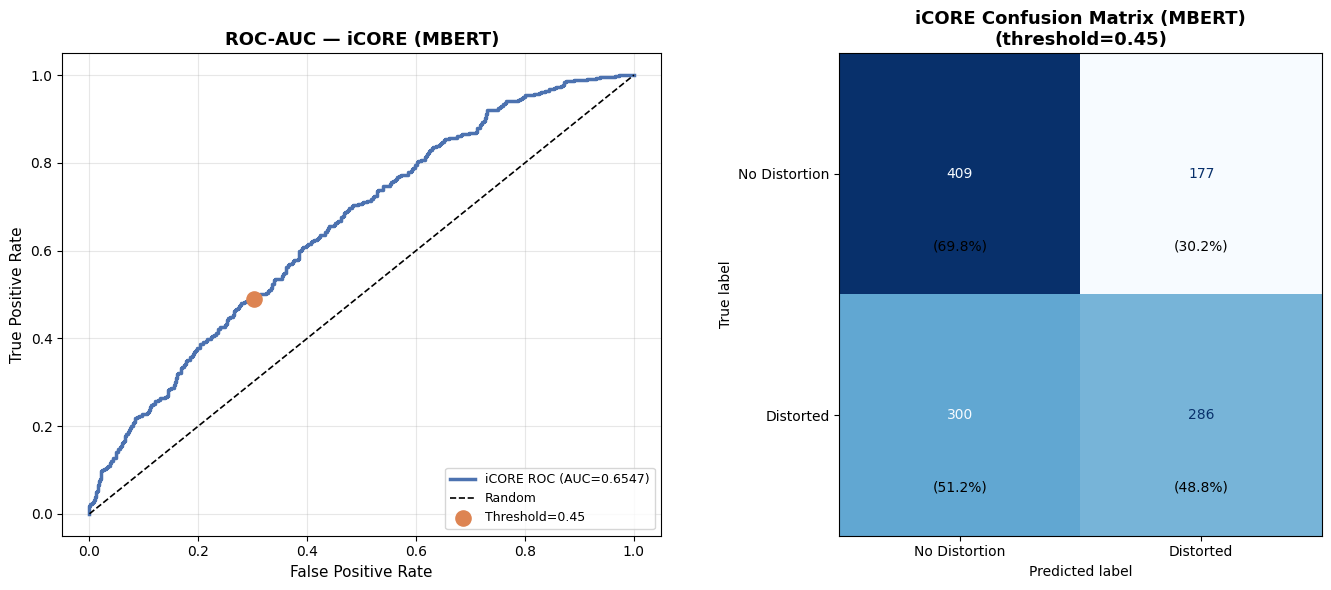

✅ Saved: ./visualizations/icore_mbert_results.png


In [13]:
# ============================================================
# BLOCK 12 — VISUALIZATION
# ROC curve + confusion matrix
# ============================================================
os.makedirs("./visualizations", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — ROC curve
best_thr_idx_ic = np.argmin(np.abs(thr_ic - best_threshold))
axes[0].plot(fpr_ic, tpr_ic, color="#4C72B0", linewidth=2.5,
             label=f"iCORE ROC (AUC={roc_auc_ic:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Random")
axes[0].scatter(fpr_ic[best_thr_idx_ic], tpr_ic[best_thr_idx_ic],
                color="#DD8452", s=120, zorder=5,
                label=f"Threshold={best_threshold}")
axes[0].set_title(f"ROC-AUC — iCORE ({MODEL_CHOICE.upper()})",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate",  fontsize=11)
axes[0].legend(fontsize=9, loc="lower right")
axes[0].grid(True, alpha=0.3)

# Right — Confusion matrix
cm_ic = confusion_matrix(icore_y_true, icore_y_pred_thr)
disp  = ConfusionMatrixDisplay(
    confusion_matrix=cm_ic,
    display_labels=["No Distortion", "Distorted"]
)
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
for i in range(cm_ic.shape[0]):
    for j in range(cm_ic.shape[1]):
        pct = cm_ic[i, j] / cm_ic[i].sum() * 100
        axes[1].text(j, i + 0.3, f"({pct:.1f}%)",
                     ha="center", va="center",
                     fontsize=10, color="black")
axes[1].set_title(
    f"iCORE Confusion Matrix ({MODEL_CHOICE.upper()})\n(threshold={best_threshold})",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
save_path = f"./visualizations/icore_{MODEL_CHOICE}_results.png"
plt.savefig(save_path, dpi=150)
plt.show()
print(f"✅ Saved: {save_path}")

In [14]:
# ============================================================
# BLOCK 13 — DOWNLOAD OUTPUTS
# ============================================================
import shutil
from google.colab import files

# Download predictions CSV
shutil.copy("./icore_predictions.csv", "./mbert_icore_predictions.csv")
files.download("./mbert_icore_predictions.csv")

# Download visualization
files.download(f"./visualizations/icore_{MODEL_CHOICE}_results.png")

print("✅ Files downloading")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloading
